In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from collections import defaultdict
import itertools as it
datadir0  ='/nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assemble_Dome/'
plotsdir = '/nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assemble_Dome/Plotting/Plots/'

import sys
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(20000)

Current recursion limit: 3000


In [2]:
# import os
# from collections import defaultdict

# import numpy as np
# import pandas as pd




def canonical_edge(a, b):
    return (a, b) if a <= b else (b, a)


def compute_monomer_lifetime_for_folder(folder_bonds, start_t, end_t):
    """
    Compute monomer lifetime in a single simulation.

    - 'Monomers' are nodes appearing in type-1 bonds.
    - 'Free monomers' are monomer nodes with zero type-2/3 bonds.
    - We count only transitions between NETWORK <-> FREE for lifetime.
    - Nucleation/death of free monomers are tracked separately and excluded
      from the turnover rate used for lifetime.
    """

    files = sorted(
        (f for f in os.listdir(folder_bonds) if os.path.isfile(os.path.join(folder_bonds, f))),
        key=lambda fn: float(fn[13:])
    )

    prev_free_set     = None
    prev_monomer_ids  = None
    prev_time         = None

    times             = []
    release_rates     = []  # true network→free
    incorp_rates      = []  # true free→network
    birth_free_rates  = []  # nucleation into free pool
    death_free_rates  = []  # death from free pool
    nummonomers       = []  # proxy for monomer population (type-1 bond count)

    for fn in files:
        tval = float(fn[13:])
        fp   = os.path.join(folder_bonds, fn)

        df = pd.read_csv(
            fp, header=None, skiprows=9, sep=r"\s+", usecols=[1, 2, 3], engine="python",
            names=["p1", "p2", "type"]
        )

        # --- Build edges by type ---
        edges_by_type = defaultdict(set)
        for row in df.itertuples(index=False):
            edges_by_type[int(row.type)].add(canonical_edge(int(row.p1), int(row.p2)))

        # --- Monomer nodes: appear in type-1 bonds ---
        type1_edges = edges_by_type.get(1, set())
        monomer_ids = set()
        for a, b in type1_edges:
            monomer_ids.add(a)
            monomer_ids.add(b)

        # --- Degree wrt type-2/3 bonds ---
        deg23 = defaultdict(int)
        for t in (2, 3):
            for a, b in edges_by_type.get(t, set()):
                deg23[a] += 1
                deg23[b] += 1

        # --- Free monomers at this frame ---
        curr_free_set = {n for n in monomer_ids if deg23[n] == 0}

        # Track population proxy (type-1 bond count)
        nummonomers.append(int((df["type"] == 1).sum()))

        if prev_free_set is not None and prev_monomer_ids is not None:
            dt = tval - prev_time
            if dt <= 0:
                dt = 1.0

            # --- Birth/death of monomer IDs (from having type-1 bonds) ---
            births = monomer_ids - prev_monomer_ids
            deaths = prev_monomer_ids - monomer_ids

            births_free = births & curr_free_set       # newly nucleated & free
            deaths_free = deaths & prev_free_set       # free monomers that died

            # --- Raw free set changes ---
            entered_free_raw = curr_free_set - prev_free_set  # would be "releases"
            left_free_raw    = prev_free_set - curr_free_set  # would be "incorporations"

            # --- Remove birth/death contributions from lifetime flux ---
            entered_free = entered_free_raw - births_free     # true network→free
            left_free    = left_free_raw - deaths_free        # true free→network

            n_release      = len(entered_free)
            n_incorp       = len(left_free)
            n_births_free  = len(births_free)
            n_deaths_free  = len(deaths_free)

            times.append(tval)
            release_rates.append(n_release / dt)
            incorp_rates.append(n_incorp / dt)
            birth_free_rates.append(n_births_free / dt)
            death_free_rates.append(n_deaths_free / dt)

        prev_free_set    = curr_free_set
        prev_monomer_ids = monomer_ids
        prev_time        = tval

    if len(times) == 0:
        return np.nan, {}

    times            = np.asarray(times)
    release_rates    = np.asarray(release_rates, dtype=float)
    incorp_rates     = np.asarray(incorp_rates, dtype=float)
    birth_free_rates = np.asarray(birth_free_rates, dtype=float)
    death_free_rates = np.asarray(death_free_rates, dtype=float)
    nummonomers      = np.asarray(nummonomers, dtype=float)

    # Restrict to time window for rate averages
    mask = (times >= start_t) & (times <= end_t)
    if not np.any(mask):
        return np.nan, {}

    avg_release = release_rates[mask].mean()
    avg_incorp  = incorp_rates[mask].mean()
    avg_rate    = 0.5 * (avg_release + avg_incorp)

    #mean_n_mon  = nummonomers.mean()
    n_mon_aligned = nummonomers[1:]  # align with times/release_rates/etc
    mean_n_mon = n_mon_aligned[mask].mean()
    lifetime   = mean_n_mon / avg_rate if avg_rate > 0 else np.nan
    lifetime    = mean_n_mon / avg_rate if avg_rate > 0 else np.nan #mean_n_mon

    # Baseline nucleation/death stats (optional to use)
    avg_birth_free = birth_free_rates[mask].mean() if len(birth_free_rates) else 0.0
    avg_death_free = death_free_rates[mask].mean() if len(death_free_rates) else 0.0

    baseline = {
        "avg_release": avg_release,
        "avg_incorp": avg_incorp,
        "avg_rate": avg_rate,
        "avg_birth_free": avg_birth_free,
        "avg_death_free": avg_death_free,
        "mean_n_mon": mean_n_mon,
    }

    return lifetime, baseline, nummonomers,times,release_rates,incorp_rates,birth_free_rates,death_free_rates

/nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assemble_Dome//runs_BondSample/run_kappaD0.01_teq1e6_Frames10_tstep0.001_Nev5000_KangNC14.0_MonsPref10_MP0.01_MP0.01_FactMu0.66_MD0.65_BD1.35_MD0.65_BD0.95_seed1
B4 0.01 1
Start, End 0 1000000000.0
MP=0.01, seed=1 → lifetime=14.201×10^6 ; release=9.7e-05, incorp=0.000106, birth_free=0.00102, death_free=0.00101Number of mons = 1.44e+03
/nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assemble_Dome//runs_BondSample/run_kappaD0.01_teq1e6_Frames10_tstep0.001_Nev5000_KangNC14.0_MonsPref10_MP0.01_MP0.01_FactMu0.66_MD0.65_BD1.35_MD0.65_BD0.95_seed2
B4 0.01 2
Start, End 0 1000000000.0
MP=0.01, seed=2 → lifetime=11.851×10^6 ; release=0.000112, incorp=0.000129, birth_free=0.00135, death_free=0.00134Number of mons = 1.43e+03
/nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assemble_Dome//runs_BondSample/run_kappaD0.01_teq1e6_Frames10_tstep0.001_Nev5000_KangNC14.0_MonsPref10_

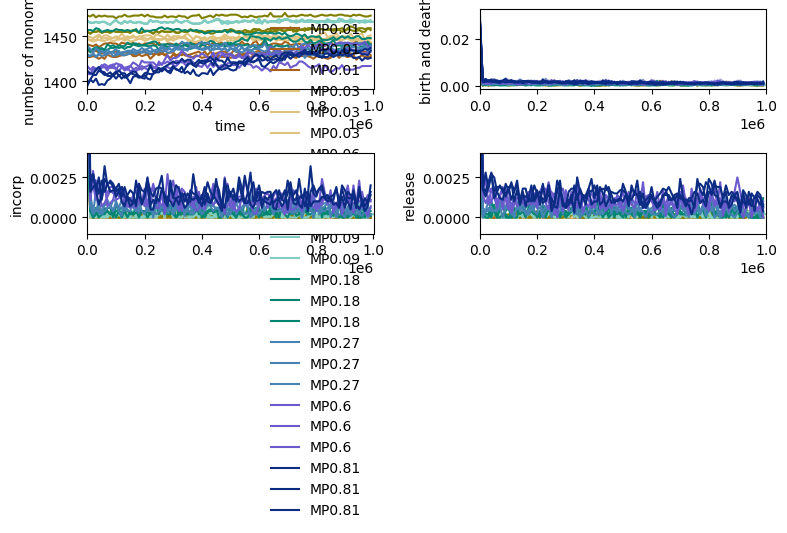

In [5]:
IndividualT_MonRelaseTot = []
IndividualT_MonRelaseStd = []

seeds0    = ["1", "2", "3"] #,"1", "2", "3"
seeds    = ["1", "2", "3","4"]
MPs      = [0.01, 0.03, 0.06, 0.09, 0.18, 0.27, 0.6, 0.81] #
MonPref  = "10 10 10 10 10 10 10 10".split()

Start, End = 0, 1e9   # time window for averaging rates 0.5e6

fig,ax=plt.subplots(2,2,figsize = (8,6))
for tt, bd in enumerate(MPs):
    lifetimes_this_MP = []

    for s, seed in enumerate(seeds0):
        # if s==2 and tt==1:
        #     continue
        # if s==2 and tt==2:
        #     continue
        if tt==2 or tt==3:
            if s==2:
                seed="4"
                
        fname = (
            f"{datadir0}/runs_BondSample/"
            f"run_kappaD0.01_teq1e6_Frames10_tstep0.001_Nev5000_"
            f"KangNC14.0_MonsPref{MonPref[tt]}_MP{bd}_MP{bd}_FactMu0.66_"
            f"MD0.65_BD1.35_MD0.65_BD0.95_seed{seed}"
        )
        print(fname)
        folder_bonds = os.path.join(fname, "dumplin_bonds_Sample")

        #lifetime, baseline = compute_monomer_lifetime_for_folder(folder_bonds, Start, End)
        print("B4",bd, seed)
        lifetime, baseline,monsInTime,times,release_rates,incorp_rates,birth_free_rates,death_free_rates = compute_monomer_lifetime_for_folder(folder_bonds, Start, End)
        print("Start, End",Start, End)
        ax[0,0].plot(np.subtract(times,times[0]),monsInTime[1:],color = clrs[tt],label = "MP"+str(MPs[tt]))
        if tt==0:
            ax[1,1].plot(np.subtract(times,times[0]),release_rates,color = clrs[tt],label = "release")
            ax[1,0].plot(np.subtract(times,times[0]),incorp_rates,color = clrs[tt],label = "incorp")
            ax[0,1].plot(np.subtract(times,times[0]),birth_free_rates,color = clrs[tt],label = "Birth")
            ax[0,1].plot(np.subtract(times,times[0]),death_free_rates,color = clrs[tt],alpha = 0.5,label = "Death")
        else:
            ax[1,1].plot(np.subtract(times,times[0]),release_rates,color = clrs[tt])
            ax[1,0].plot(np.subtract(times,times[0]),incorp_rates,color = clrs[tt])
            ax[0,1].plot(np.subtract(times,times[0]),birth_free_rates,color = clrs[tt])
            ax[0,1].plot(np.subtract(times,times[0]),death_free_rates,color = clrs[tt],alpha = 0.5)

        if not np.isnan(lifetime):
            lifetimes_this_MP.append(lifetime)
            print(
                f"MP={bd}, seed={seed} → lifetime={lifetime/1e6:.3f}×10^6 ; "
                f"release={baseline.get('avg_release',0):.3g}, "
                f"incorp={baseline.get('avg_incorp',0):.3g}, "
                f"birth_free={baseline.get('avg_birth_free',0):.3g}, "
                f"death_free={baseline.get('avg_death_free',0):.3g}"
                f"Number of mons = {baseline.get('mean_n_mon',0):.3g}"
            )

    if len(lifetimes_this_MP) == 0:
        IndividualT_MonRelaseTot.append(np.nan)
        IndividualT_MonRelaseStd.append(np.nan)
    else:
        IndividualT_MonRelaseTot.append(np.mean(lifetimes_this_MP))
        IndividualT_MonRelaseStd.append(np.std(lifetimes_this_MP))

print("MPs:            ", MPs)
print("Mean lifetimes: ", IndividualT_MonRelaseTot)
print("Std (across seeds):", IndividualT_MonRelaseStd)

ax[0,0].set_xlabel("time")
ax[0,0].set_ylabel("number of monomers")
ax[1,0].set_ylabel("incorp")
ax[1,1].set_ylabel("release")
ax[0,1].set_ylabel("birth and death")
ax[1,0].set_ylim([-0.001,0.004])
ax[1,1].set_ylim([-0.001,0.004])
ax[0,0].set_xlim([0,1e6])
ax[0,1].set_xlim([0,1e6])
ax[1,0].set_xlim([0,1e6])
ax[1,1].set_xlim([0,1e6])
ax[0,0].legend(frameon=False)
fig.tight_layout()

[127.79455408 101.83647591  78.36953548  57.06806476  33.70755082
  20.44629211  11.65913445   9.42916963]
[10.20709891  7.75092837  0.61824433  5.91103751  1.71577276  0.51006048
  0.27681563  0.30572506]
[0.01, 0.03, 0.06, 0.09, 0.18, 0.27, 0.6, 0.81]


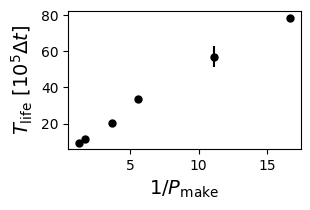

In [8]:
#fig,ax = plt.subplots(figsize = (4,2.7))
fig,ax = plt.subplots(figsize = (3,1.8))
x = np.divide(np.divide(1,MPs), 1)
y = np.divide(IndividualT_MonRelaseTot,1e5)
yerr = np.divide(IndividualT_MonRelaseStd,1e5)

# x = np.divide(TLifeDenseControl[:-2], 1e5)
# y = np.divide(Taus_Av[:-2], 1e5)
# yerr = np.divide(Taus_Std[:-2], 1e5)
# xerr = np.divide(TLifeDenseControlSTD[:-2], 1e5)

ax.errorbar(x[2:], y[2:], yerr=yerr[2:], marker='o', linestyle='none',markersize = 5,color = 'black')

# ---- Linear best fit ----
# Fit: y = m x + b
m, b = np.polyfit(x, y, deg=1)

# Generate fit line
x_fit = np.linspace(min(x), max(x), 200)
y_fit = m * x_fit + b
#ax.errorbar(np.divide(1,MPs), np.divide(IndividualT_MonRelaseTot,1e5),yerr = np.divide(IndividualT_MonRelaseStd,1e5),marker = 'o',capsize = 3,markersize = 2)
#ax.plot(-np.log(MPs), np.divide(IndividualT_MonRelaseTot,1e5),marker = 'o',markersize = 4)
#ax.plot(np.divide(1,MPs), np.divide(IndividualT_MonRelaseTot,1e5),marker = 'o',markersize = 4)
#ax.plot(x_fit, y_fit, '--', label=r'Linear fit: $T_{\mathrm{life}}$'+f' = {m:.3g}'+ r'$/P_{\mathrm{make}}$',color = 'black')
ax.set_ylabel(r'$T_{\mathrm{life}}~[10^5\Delta t]$',fontsize = 14)
ax.set_xlabel(r'$1/P_{\mathrm{make}}$',fontsize = 14)
#ax.set_ylabel(r'$\log(T_{\mathrm{life}})$',fontsize = 14)
#ax.set_xlabel(r'$\log(1/P_{\mathrm{make}})$',fontsize = 14)
##ax.set_yscale('log')
#ax.set_xscale('log')
#ax.legend(frameon=False)
#ax.set_xlabel(r'$-log(P_{\mathrm{make}})$',fontsize = 14)
print(np.divide(IndividualT_MonRelaseTot,1e5))
print(np.divide(IndividualT_MonRelaseStd,1e5))

print(MPs)

In [19]:


def canonical_edge(a, b):
    """Store bond endpoints in sorted order for stable set operations."""
    return (a, b) if a <= b else (b, a)


def dfs(graph, start, visited):
    visited.add(start)
    count = 1  # Count the starting node
    for neighbor in graph[start]:
        if neighbor not in visited:
            count += dfs(graph, neighbor, visited)  # Add count from neighbors
    return count

def build_graph(edges):
    graph = {}
    for a, b in edges:
        if a not in graph: graph[a] = []
        if b not in graph: graph[b] = []
        graph[a].append(b)
        graph[b].append(a)
    return graph

def build_graphWithTypes(edges, T):
    """
    edges: iterable of (a, b, t). Edges with type == T are EXCLUDED from connectivity.
    """
    graph = {}
    for a, b, t in edges:
        if a not in graph: graph[a] = []
        if b not in graph: graph[b] = []
        if t != T:
            graph[a].append(b)
            graph[b].append(a)
    return graph

def largest_connected_component(graph):
    visited = set()
    largest = 0
    for node in graph:
        if node not in visited:
            size = dfs(graph, node, visited)
            largest = max(largest, size)
    return largest

def number_of_monomers(graph):
    visited = set()
    monomers = 0
    for node in graph:
        if node not in visited:
            size = dfs(graph, node, visited)
            if size==2:
                monomers+=1
    return monomers

def is_connected(graph, nodes):
    visited = set()
    dfs(graph, next(iter(graph)), visited)
    return len(visited) == len(nodes)

def find_connected_components(graph, nodes):
    visited = set()
    num_components = 0
    for node in nodes:
        if node not in visited:
            dfs(graph, node, visited)
            num_components += 1
    return num_components
    
def calculate_average_degree(graph):
    total_degrees = sum(len(neighbors) for neighbors in graph.values())
    num_nodes = len(graph)
    #print(num_nodes)
    average_degree = total_degrees / num_nodes if num_nodes else 0
    return average_degree

def calculate_average_degree7sNc1(graph):
    total_degrees = sum(len(neighbors) for neighbors in graph.values())
    num_nodes = len(graph)
    #print(num_nodes)
    average_degree = total_degrees / num_nodes if num_nodes else 0
    return average_degree

In [20]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#225ea8','#0c2c84','#a6611a','#dfc27d','#80cdc1','#018571','#225ea8','#0c2c84']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
#'#f5f5f5',

10 first nb =  1 bc {1: 5, 2: 1} dt 5000.0
10 first nf =  0 fc {1: 10, 2: 0} dt 5000.0
11 first nb =  0 bc {1: 5, 2: 1, 3: 0} dt 5000.0
11 first nf =  2 fc {1: 10, 2: 0, 3: 2} dt 5000.0
20 first nb =  0 bc {1: 13, 2: 0, 3: 0, 4: 0} dt 5000.0
20 first nf =  0 fc {1: 14, 2: 0, 3: 2, 4: 0} dt 5000.0
21 first nb =  14 bc {1: 14} dt 5000.0
21 first nf =  10 fc {1: 10} dt 5000.0
[12905000.0, 12910000.0, 12915000.0, 12920000.0, 12925000.0, 12930000.0, 12935000.0, 12940000.0, 12945000.0, 12950000.0, 12955000.0, 12960000.0, 12965000.0, 12970000.0, 12975000.0, 12980000.0, 12985000.0, 12990000.0, 12995000.0, 13000000.0, 13005000.0, 13010000.0, 13015000.0, 13020000.0, 13025000.0, 13030000.0, 13035000.0, 13040000.0, 13045000.0, 13050000.0, 13055000.0, 13060000.0, 13065000.0, 13070000.0, 13075000.0, 13080000.0, 13085000.0, 13090000.0, 13095000.0, 13100000.0, 13105000.0, 13110000.0, 13115000.0, 13120000.0, 13125000.0, 13130000.0, 13135000.0, 13140000.0, 13145000.0, 13150000.0, 13155000.0, 13160000.0,

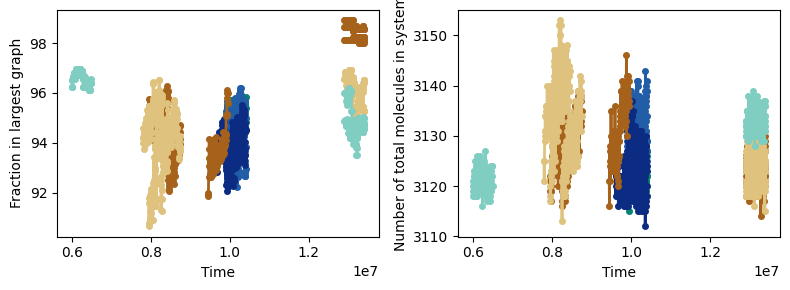

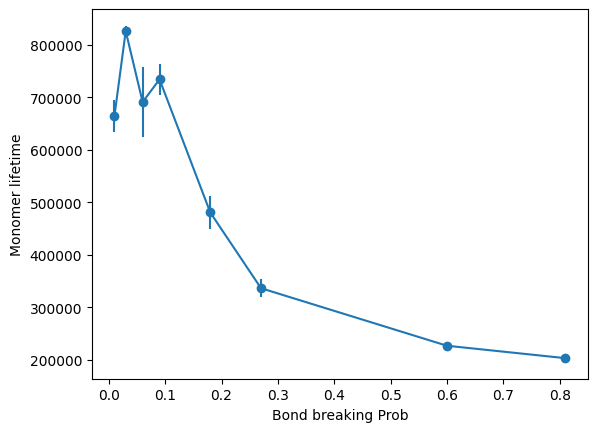

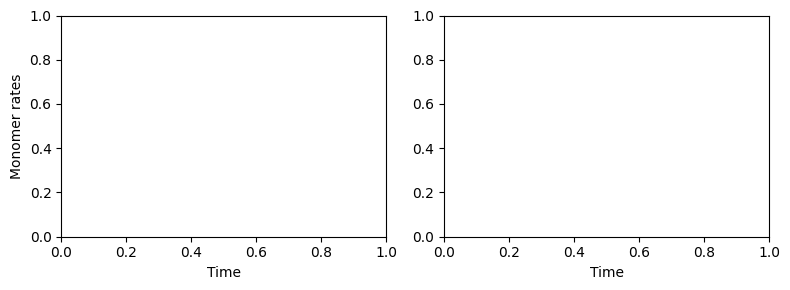

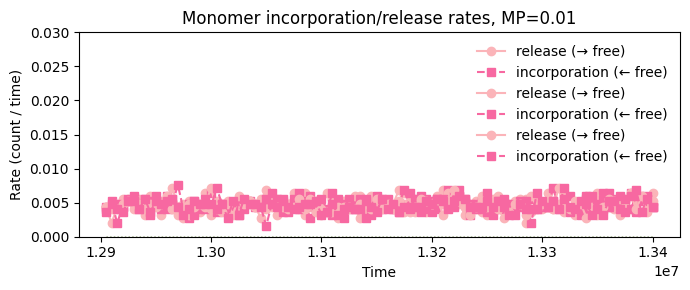

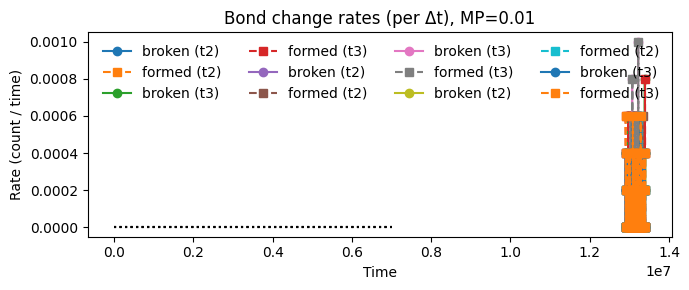

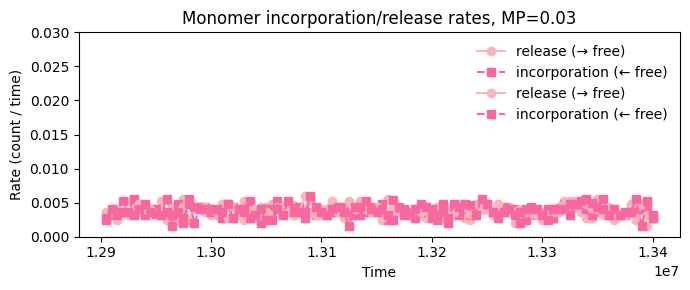

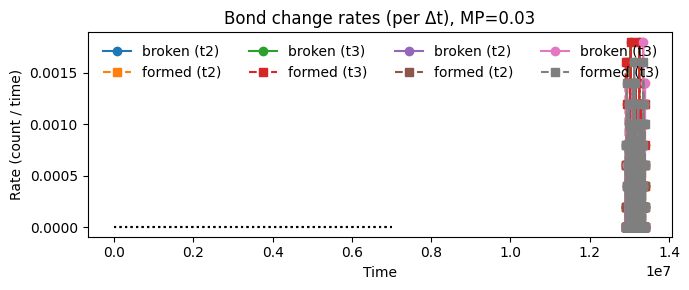

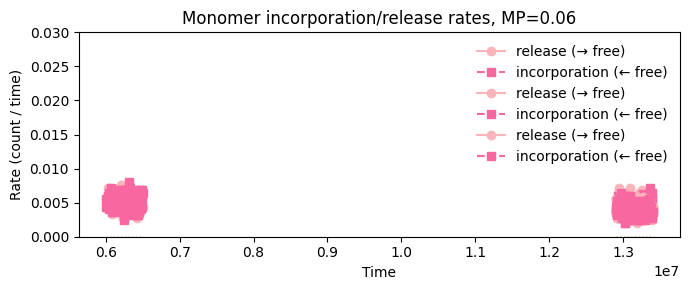

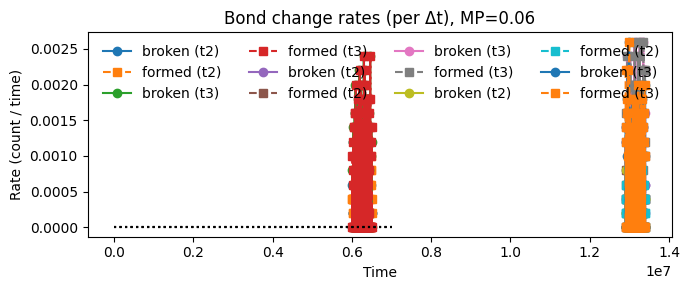

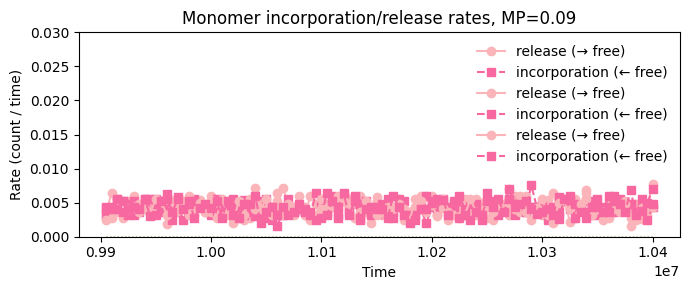

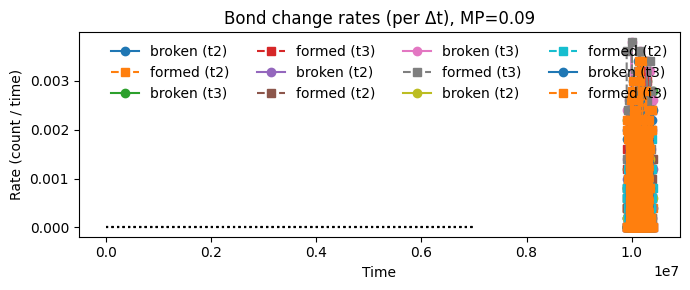

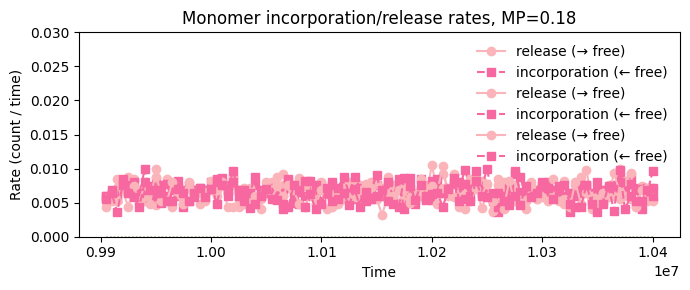

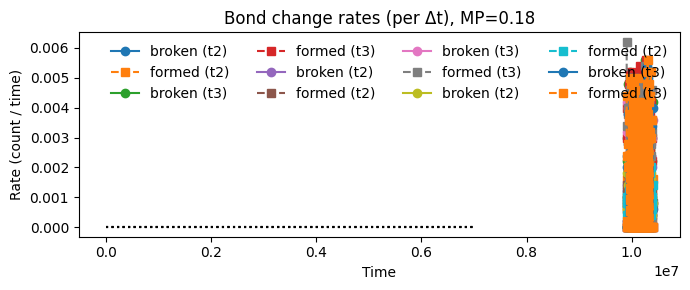

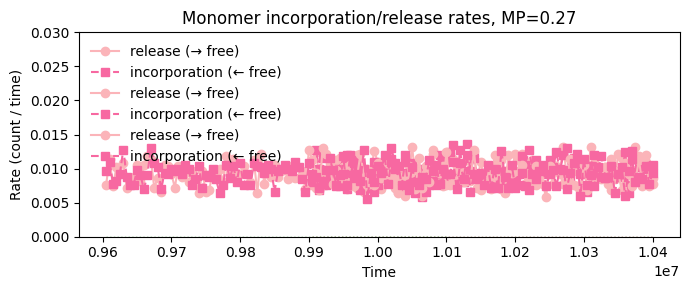

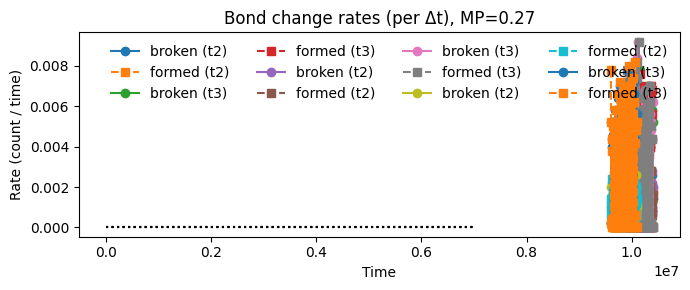

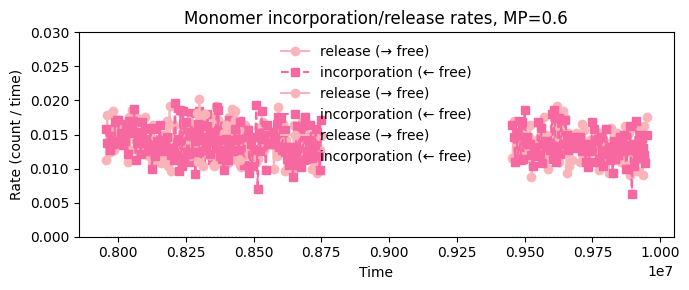

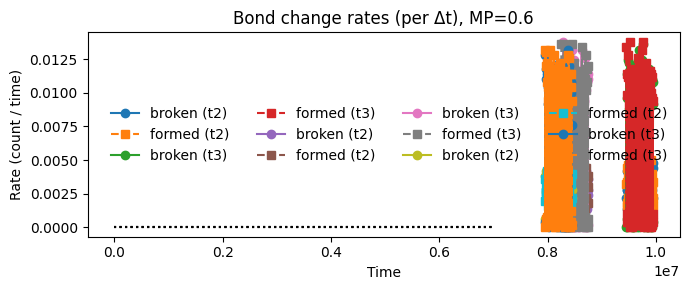

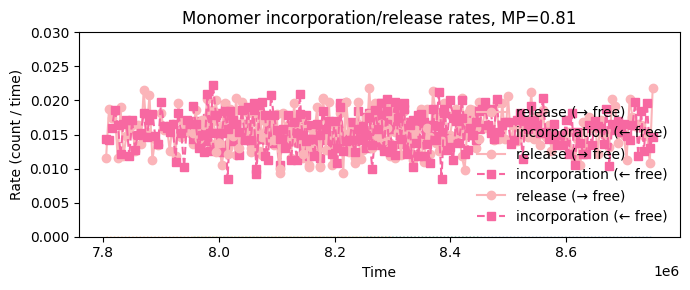

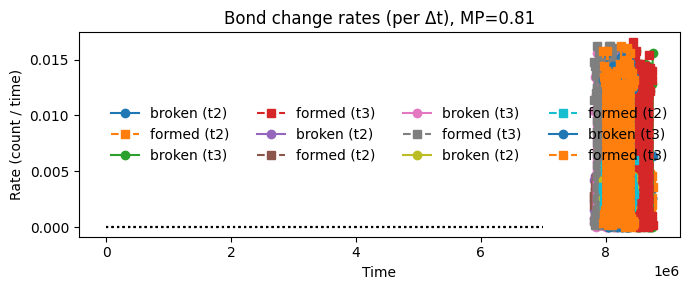

In [21]:


# === FIGURES ===
fig, ax   = plt.subplots(1, 2, figsize=(8, 3))
fig3, ax3 = plt.subplots()
fig2, ax2 = plt.subplots(1, 2, figsize=(8, 3))

# === CONSTANTS / PARAMS ===
NumAtoms = 6250
seeds    = ["1","2","3"]
MPs = [0.01,0.03,0.06,0.09,0.18,0.27,0.6,0.81] #
MonPref = "12 9 11 8 13 17 26 31".split() # 17 26 31
#MonomerRatesAll     = []
IndividualT_MonRelaseTot = []
IndividualT_MonRelaseStd = []
c=0
# --- Monomer incorporation/release tracking ---

# === MAIN LOOPS ===
Start=0
End=1e9
for tt, bd in enumerate(MPs):
    IndividualT_MonRelaseInd = []
    fig_m, ax_m = plt.subplots(figsize=(7,3))
    fig_rates, ax_rates = plt.subplots(figsize=(7, 3))
    for s, seed in enumerate(seeds):
        if s==0 and tt==1:
            continue
        fname = (
            f"{datadir0}/runs_BondSample/run_kappaD0.01_teq5e5_Frames10_tstep0.01_Nev2000_KangNC14.0_MP{bd}_MP{bd}_FactMu0.66_MonsPref{MonPref[tt]}_MD0.65_BD1.35_MD0.65_BD0.95_seed{seed}")
        
        folder_bonds = os.path.join(fname, "dumplin_bonds_Sample")
        files = sorted(
            (f for f in os.listdir(folder_bonds) if os.path.isfile(os.path.join(folder_bonds, f))),
            key=lambda fn: float(fn[13:])  # keep your time parsing
        )

        # Per-condition accumulators
        timeNR, LargestCompNR, nummonomers = [], [], []
        interval_times = []
        broken_counts_by_type, formed_counts_by_type = [], []
        broken_rates_by_type, formed_rates_by_type   = [], []
        prev_edges_by_type, prev_time = None, None

        # Output text files
        fileOUT1 = os.path.join(fname, "LargestComp.txt")
        fileOUT2 = os.path.join(fname, "NumMons.txt")

        free_set_times = []           # time at the end of interval
        release_counts = []           # |entered free|
        incorp_counts  = []           # |left free|
        release_rates  = []           # per dt
        incorp_rates   = []           # per dt
        prev_free_set  = None         # set of node IDs that are free at previous frame
        with open(fileOUT1, "w") as f1, open(fileOUT2, "w") as f2:

            for fn in files:
                tval = float(fn[13:])
                timeNR.append(tval)
                fp = os.path.join(folder_bonds, fn)

                # Read once: p1, p2, type
                df = pd.read_csv(
                    fp, header=None, skiprows=9, sep=r"\s+", usecols=[1, 2, 3], engine="python",
                    names=["p1", "p2", "type"]
                )

                # Build current edges by type
                curr_edges_by_type = defaultdict(set)
                for row in df.itertuples(index=False):
                    curr_edges_by_type[int(row.type)].add(canonical_edge(int(row.p1), int(row.p2)))
                # Nodes that appear in any type-1 bond (monomer nodes by your definition)
                type1_edges = curr_edges_by_type.get(1, set())
                type1_nodes = set()
                for a, b in type1_edges:
                    type1_nodes.add(a)
                    type1_nodes.add(b)
                
                # Degrees with respect to type 2/3 bonds
                deg23 = defaultdict(int)
                for t in (2, 3):
                    for a, b in curr_edges_by_type.get(t, set()):
                        deg23[a] += 1
                        deg23[b] += 1
                
                # Current "free monomers": have at least one type-1 bond and zero type-2/3 bonds
                curr_free_set = {n for n in type1_nodes if deg23[n] == 0}


                # Diff vs previous frame
                if prev_edges_by_type is not None:
                    dt = tval - prev_time if tval != prev_time else 1.0
                    all_types = set(curr_edges_by_type) | set(prev_edges_by_type)

                    bc, fc, br, fr = {}, {}, {}, {}
                    for t in all_types:
                        prev_set = prev_edges_by_type.get(t, set())
                        curr_set = curr_edges_by_type.get(t, set())
                        nb = len(prev_set - curr_set)   # broken Gives the bonds which were there in previous but not current
                        
                        c+=1
                        nf = len(curr_set - prev_set)   # formed Gives the bonds which are there in current but not previous
                        bc[t], fc[t] = nb, nf
                        br[t], fr[t] = nb / dt, nf / dt #Rates
                        if c==10 or c==11 or c==20 or c==21:
                            print(c,"first nb = ",nb,"bc",bc,"dt",dt) # nb,nf are integers
                            print(c,"first nf = ",nf,"fc",fc,"dt",dt) #bc,fc are 'sets' : {1: 1, 2: 94, 3: 411}

                    interval_times.append(tval)
                    broken_counts_by_type.append(bc)
                    formed_counts_by_type.append(fc)
                    broken_rates_by_type.append(br)
                    formed_rates_by_type.append(fr)

                    # --- Free-monomer transitions ---
                    if prev_free_set is not None:
                        entered_free = curr_free_set - prev_free_set   # RELEASE events
                        left_free    = prev_free_set - curr_free_set   # INCORPORATION events
                
                        free_set_times.append(tval)
                        release_counts.append(len(entered_free))
                        incorp_counts.append(len(left_free))
                        release_rates.append(len(entered_free) / dt)
                        incorp_rates.append(len(left_free) / dt)

                prev_edges_by_type, prev_time = curr_edges_by_type, tval
                prev_edges_by_type, prev_time = curr_edges_by_type, tval
                prev_free_set = curr_free_set

                # numnodes = number of bonds of type 1
                numnodes_val = int((df["type"] == 1).sum())
                nummonomers.append(numnodes_val)

                # Largest component using edges (ignore type)
                edges = df[["p1", "p2"]].to_numpy()
                G = build_graph(edges)  # you already have this
                LC = largest_connected_component(G)  # and this
                LargestCompNR.append(LC)

                f1.write(f"{tval} {LC}\n")
                f2.write(f"{tval} {numnodes_val}\n")

        # --- Assemble tidy table for plotting diffs ---
        # Collect all seen types
        all_types_seen = sorted({t for d in broken_counts_by_type for t in d} |
                                {t for d in formed_counts_by_type for t in d})
        all_types_seen = [2,3]

        rows = []
        print(interval_times)
        if len(interval_times)<3:
            continue
        for k, t_end in enumerate(interval_times):
            for bt in all_types_seen:
                rows.append({
                    "t_end": t_end,
                    "type": bt,
                    "broken_count": broken_counts_by_type[k].get(bt, 0),
                    "formed_count": formed_counts_by_type[k].get(bt, 0),
                    "broken_rate":  broken_rates_by_type[k].get(bt, 0.0),
                    "formed_rate":  formed_rates_by_type[k].get(bt, 0.0),
                })
        bond_changes_df = pd.DataFrame(rows).sort_values(["t_end", "type"])
        
        # --- Plots for this MP ---
        xt = np.array(interval_times)
        if len(xt) > 0:
            # 2) Lines: broken/formed rates by type
            
            for bt in all_types_seen:
                # vals = (bond_changes_df.query("type == @bt")
                #         .set_index("t_end")
                #         .reindex(xt)["broken_count"]
                #         .fillna(0).to_numpy())
                df_bt = bond_changes_df.query("type == @bt")
                ax_rates.plot(df_bt["t_end"], df_bt["broken_rate"], marker="o", lw=1.5, label=f"broken (t{bt})")
                #ax_rates.plot(df_bt["t_end"], vals, marker="o", lw=1.5, label=f"broken (t{bt})")
                ax_rates.plot(df_bt["t_end"], df_bt["formed_rate"], marker="s", lw=1.5, ls="--", label=f"formed (t{bt})")
                tIndex1 = int(np.argmin(np.abs(df_bt["t_end"] - 0)))
                tIndex2 = int(np.argmax(np.abs(df_bt["t_end"])))
                print('BD7s',bd,"average breaking",bt,np.mean(df_bt["broken_rate"][tIndex1:tIndex2]))
            ax_rates.set_title(f"Bond change rates (per Δt), MP={bd}")
            ax_rates.set_xlabel("Time")
            ax_rates.set_ylabel("Rate (count / time)")
            ax_rates.legend(frameon=False, ncol=min(4, 2 * len(all_types_seen)))
            #ax_rates.set_ylim([0.8,1.2]) ##-0.001,0.001])
            ax_rates.plot([0,7e6],[0,0],color = 'black',linestyle = ':')
            fig_rates.tight_layout()

        # 3) Your existing overview panels
        #    - Largest component fraction
        denom = (nummonomers[-1] if nummonomers else 1) * 2 * 0.01
        ax[0].plot(timeNR, np.array(LargestCompNR) / denom,
                   color=clrs[MPs.index(bd)], lw=2, marker="o", ms=4, label=f"{bd}")

        #    - Total molecules in system (actually nummonomers)
        ax[1].plot(timeNR, nummonomers, color=clrs[MPs.index(bd)], lw=2, marker="o", ms=4)

        monomer_events_df = pd.DataFrame({
            "t_end": free_set_times,
            "release_count": release_counts,
            "incorp_count":  incorp_counts,
            "release_rate":  release_rates,
            "incorp_rate":   incorp_rates,
        }).sort_values("t_end")

        mask = (monomer_events_df["t_end"] >= 0) & (monomer_events_df["t_end"] <= 1e9)
        subset = monomer_events_df.loc[mask]
        
        if not subset.empty:
            # Average only over this window
            AvRates = np.mean([subset["incorp_rate"].mean(), subset["release_rate"].mean()])
        else:
            AvRates = np.nan  # fallback if no data in window
        
        # Same for the number of monomers — assuming nummonomers corresponds 1:1 to frames
        NumInNetwork = np.mean(nummonomers)
        
        # Compute lifetime
        lifetime = NumInNetwork / AvRates
        IndividualT_MonRelaseInd.append(lifetime)
        
        print("Monomer lifetime [10^6]", lifetime / 1e6)
        # Example: average rates between Start and End
        if len(monomer_events_df) > 0:
            t1 = monomer_events_df["t_end"].sub(Start).abs().idxmin()
            t2 = monomer_events_df["t_end"].sub(End).abs().idxmin()
            lo, hi = sorted([t1, t2])
            avg_release = monomer_events_df["release_rate"].iloc[lo:hi].mean()
            avg_incorp  = monomer_events_df["incorp_rate"].iloc[lo:hi].mean()
            print(f"Avg release rate: {avg_release:.6g}")
            print(f"Avg incorporation rate: {avg_incorp:.6g}")
        
            # Quick plot
            
            ax_m.plot(monomer_events_df["t_end"], monomer_events_df["release_rate"], marker="o", lw=1.5, label="release (→ free)",color = "#fbb4b9")
            ax_m.plot(monomer_events_df["t_end"], monomer_events_df["incorp_rate"],  marker="s", lw=1.5, ls="--", label="incorporation (← free)",color = "#f768a1")
            ax_m.set_xlabel("Time")
            ax_m.set_ylabel("Rate (count / time)")
            ax_m.set_title(f"Monomer incorporation/release rates, MP={bd}")
            ax_m.legend(frameon=False)
            ax_m.plot([monomer_events_df["t_end"].min(), monomer_events_df["t_end"].max()], [0,0], linestyle=":", lw=1)
            ax_m.set_ylim([0,0.03])
            fig_m.tight_layout()
            
    IndividualT_MonRelaseTot.append(np.mean(IndividualT_MonRelaseInd))
    IndividualT_MonRelaseStd.append(np.std(IndividualT_MonRelaseInd))

# === Final labels/layout ===
ax3.errorbar(MPs, IndividualT_MonRelaseTot,yerr = IndividualT_MonRelaseStd,marker = 'o')
ax3.set_ylabel("Monomer lifetime")
ax3.set_xlabel("Bond breaking Prob")

#ax[0].legend(frameon=False)
ax[1].set_ylabel("Number of total molecules in system")
ax[0].set_ylabel("Fraction in largest graph")
ax[0].set_xlabel("Time")
ax[1].set_xlabel("Time")
ax2[0].set_xlabel("Time")
ax2[1].set_xlabel("Time")
ax2[0].set_ylabel("Monomer rates")

fig.tight_layout()
fig2.tight_layout()


[6.64387333 8.2592173  6.90735542 7.33934768 4.80411845 3.36172058
 2.26585949 2.02941306]
[0.29984738 0.09838317 0.66048894 0.29865342 0.31500953 0.17521854
 0.05613306 0.07166307]
[0.01, 0.03, 0.06, 0.09, 0.18, 0.27, 0.6, 0.81]


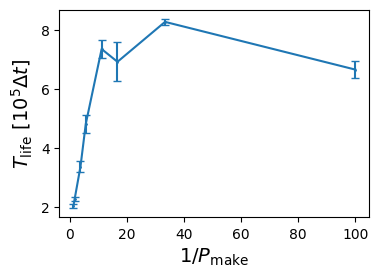

In [22]:
fig,ax = plt.subplots(figsize = (4,2.7))

ax.errorbar(np.divide(1,MPs), np.divide(IndividualT_MonRelaseTot,1e5),yerr = np.divide(IndividualT_MonRelaseStd,1e5),marker = 'o',capsize = 3,markersize = 1)
#ax.plot(-np.log(MPs), np.divide(IndividualT_MonRelaseTot,1e5),marker = 'o',markersize = 4)
#ax.plot(np.divide(1,MPs), np.divide(IndividualT_MonRelaseTot,1e5),marker = 'o',markersize = 4)

ax.set_ylabel(r'$T_{\mathrm{life}}~[10^5\Delta t]$',fontsize = 14)
ax.set_xlabel(r'$1/P_{\mathrm{make}}$',fontsize = 14)

#ax.set_xlabel(r'$-log(P_{\mathrm{make}})$',fontsize = 14)
print( np.divide(IndividualT_MonRelaseTot,1e5))
print( np.divide(IndividualT_MonRelaseStd,1e5))

print(MPs)


In [23]:
# import os
# from collections import defaultdict

# import numpy as np
# import pandas as pd

# === USER PARAMS =====================================================

seeds    = ["1", "2", "3"]
MPs      = [0.01,0.03,0.06,0.09,0.18,0.27,0.6,0.81]
MonPref  = "12 9 11 8 13 17 26 31".split()

# time window over which to average rates (use very wide range = "all")
Start, End = 0.0, 1e9


# === CORE LOGIC ======================================================

def canonical_edge(a, b):
    """Store edges in a canonical (sorted) order so set-differences work."""
    return (a, b) if a <= b else (b, a)


def compute_monomer_lifetime_for_folder(folder_bonds, start_t, end_t):
    """
    Compute the monomer lifetime for a single simulation (single seed, single MP).

    Steps:
    1. For each frame, find the set of "free monomer" nodes:
       - Nodes that appear in at least one type-1 bond.
       - And that have degree 0 with respect to type-2/3 bonds.
    2. Between consecutive frames, count transitions:
       - entered_free = curr_free - prev_free  (RELEASE events)
       - left_free    = prev_free - curr_free (INCORPORATION events)
    3. Convert counts to rates by dividing by Δt.
    4. Average release/incorporation rates over the chosen time window.
    5. Compute mean number of monomers in the network (from type-1 bonds).
    6. Lifetime = (mean # monomers in network) / (mean event rate).
    """

    # List of bond files, sorted by their numeric time (assumes pattern ..._<time>)
    files = sorted(
        (f for f in os.listdir(folder_bonds) if os.path.isfile(os.path.join(folder_bonds, f))),
        key=lambda fn: float(fn[13:])  # keep your time parsing convention
    )

    prev_free_set = None
    prev_time     = None

    times          = []  # times at which we have a rate
    release_rates  = []
    incorp_rates   = []
    nummonomers    = []  # number of type-1 bonds at each frame

    for fn in files:
        tval = float(fn[13:])
        fp   = os.path.join(folder_bonds, fn)

        # Read bonds: p1, p2, type
        df = pd.read_csv(
            fp, header=None, skiprows=9, sep=r"\s+", usecols=[1, 2, 3], engine="python",
            names=["p1", "p2", "type"]
        )

        # --- Build edge sets by type ---
        edges_by_type = defaultdict(set)
        for row in df.itertuples(index=False):
            edges_by_type[int(row.type)].add(canonical_edge(int(row.p1), int(row.p2)))

        # --- Identify monomer nodes (nodes in any type-1 bond) ---
        type1_edges = edges_by_type.get(1, set())
        type1_nodes = set()
        for a, b in type1_edges:
            type1_nodes.add(a)
            type1_nodes.add(b)

        # --- Degree with respect to type-2/3 bonds ---
        deg23 = defaultdict(int)
        for t in (2, 3):
            for a, b in edges_by_type.get(t, set()):
                deg23[a] += 1
                deg23[b] += 1

        # --- Current free monomer set ---
        # (monomer nodes with no type-2/3 bonds)
        curr_free_set = {n for n in type1_nodes if deg23[n] == 0}

        # Track number of monomers in network:
        # here taken as the number of type-1 bonds in this frame
        nummonomers.append(int((df["type"] == 1).sum()))

        # --- Transition counts between frames → rates ---
        if prev_free_set is not None:
            dt = tval - prev_time
            if dt <= 0:
                dt = 1.0  # safeguard

            entered_free = curr_free_set - prev_free_set  # RELEASE events
            left_free    = prev_free_set - curr_free_set  # INCORP events

            times.append(tval)
            release_rates.append(len(entered_free) / dt)
            incorp_rates.append(len(left_free) / dt)

        prev_free_set = curr_free_set
        prev_time     = tval

    # If we never had any transitions, cannot estimate a lifetime
    if len(times) == 0 or len(release_rates) == 0:
        return np.nan

    times          = np.asarray(times)
    release_rates  = np.asarray(release_rates)
    incorp_rates   = np.asarray(incorp_rates)
    nummonomers    = np.asarray(nummonomers, dtype=float)

    # --- Restrict to chosen time window for the rate averages ---
    mask = (times >= start_t) & (times <= end_t)
    if not np.any(mask):
        return np.nan

    avg_release = release_rates[mask].mean()
    avg_incorp  = incorp_rates[mask].mean()
    avg_rate    = 0.5 * (avg_release + avg_incorp)

    # Mean number of monomers in network over entire run
    mean_n_mon = nummonomers.mean()

    # Lifetime = average population / average event rate
    lifetime = mean_n_mon / avg_rate

    return lifetime


MP=0.01, seed=1 → lifetime = 0.678 × 10^6
MP=0.01, seed=2 → lifetime = 0.623 × 10^6
MP=0.01, seed=3 → lifetime = 0.692 × 10^6
MP=0.03, seed=2 → lifetime = 0.836 × 10^6
MP=0.03, seed=3 → lifetime = 0.816 × 10^6
MP=0.06, seed=1 → lifetime = 0.599 × 10^6
MP=0.06, seed=2 → lifetime = 0.722 × 10^6
MP=0.06, seed=3 → lifetime = 0.751 × 10^6
MP=0.09, seed=1 → lifetime = 0.698 × 10^6
MP=0.09, seed=2 → lifetime = 0.733 × 10^6
MP=0.09, seed=3 → lifetime = 0.771 × 10^6
MP=0.18, seed=1 → lifetime = 0.475 × 10^6
MP=0.18, seed=2 → lifetime = 0.445 × 10^6
MP=0.18, seed=3 → lifetime = 0.521 × 10^6
MP=0.27, seed=1 → lifetime = 0.314 × 10^6
MP=0.27, seed=2 → lifetime = 0.357 × 10^6
MP=0.27, seed=3 → lifetime = 0.338 × 10^6
MP=0.6, seed=1 → lifetime = 0.234 × 10^6
MP=0.6, seed=2 → lifetime = 0.224 × 10^6
MP=0.6, seed=3 → lifetime = 0.222 × 10^6
MP=0.81, seed=1 → lifetime = 0.193 × 10^6
MP=0.81, seed=2 → lifetime = 0.211 × 10^6
MP=0.81, seed=3 → lifetime = 0.205 × 10^6
MPs:                          [0.01, 

MP=0.01, seed=1 → lifetime=22.974×10^6 ; release=0.00012, incorp=0.000152, birth_free=0.00448, death_free=0.00447
MP=0.01, seed=2 → lifetime=24.773×10^6 ; release=0.00012, incorp=0.000132, birth_free=0.00489, death_free=0.00488
MP=0.01, seed=3 → lifetime=22.979×10^6 ; release=0.000116, incorp=0.000156, birth_free=0.00438, death_free=0.00438
MP=0.03, seed=2 → lifetime=7.532×10^6 ; release=0.000402, incorp=0.000428, birth_free=0.00333, death_free=0.00332
MP=0.03, seed=3 → lifetime=7.395×10^6 ; release=0.000412, incorp=0.000432, birth_free=0.0034, death_free=0.0034
MP=0.06, seed=1 → lifetime=4.059×10^6 ; release=0.00075, incorp=0.000788, birth_free=0.00445, death_free=0.00444
MP=0.06, seed=2 → lifetime=4.085×10^6 ; release=0.000774, incorp=0.00076, birth_free=0.00357, death_free=0.00358
MP=0.06, seed=3 → lifetime=4.463×10^6 ; release=0.000742, incorp=0.000662, birth_free=0.00347, death_free=0.00346
MP=0.09, seed=1 → lifetime=2.881×10^6 ; release=0.00104, incorp=0.00113, birth_free=0.00339

[235.75374484  74.63470276  42.02458848  28.27191112  15.68679523
  10.74284254   5.41627531   4.42132864]
[8.47063389 0.68439541 1.84644942 0.38201526 0.18471379 0.39386523
 0.14234754 0.01235996]
[0.01, 0.03, 0.06, 0.09, 0.18, 0.27, 0.6, 0.81]


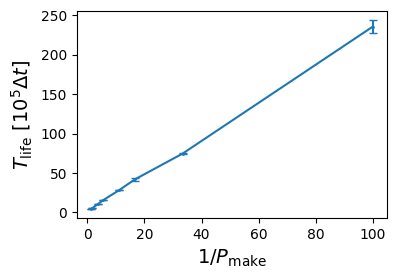